# Computer Exercise 11.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 11. Boundary-Value Problems for ODEs · **절**: §11.2 A Discretization (Finite-Difference) Method
> **주제**: **비선형** BVP의 유한차분 — **Newton 반복 + 삼중대각 Jacobian**
> **풀이 일자**: 2026-06-14 · **언어**: 한국어(본문) / English(그래프 라벨)

## 1. 문제 (원문)

> Apply the **finite-difference method** to the nonlinear boundary-value problem
> $$ y'' = \tfrac18\,\bigl(32 + 2x^3 - y\,y'\bigr), \qquad 1 \le x \le 3,
> \qquad y(1)=17,\; y(3)=\tfrac{43}{3}. $$
> Discretize $y''$ and $y'$ by centered differences, solve the resulting **nonlinear
> system** by Newton's method (the Jacobian is tridiagonal), and compare with the exact
> solution $y(x)=x^2+16/x$. Contrast with the nonlinear shooting result of §11.1.

### 한국어 풀이용 정리
Day 40 §11.1 의 **문제 2**와 *같은 비선형 BVP* 다. 사격법은 미지의 초기기울기 $s=y'(1)$ 을
**할선법**으로 맞춰 $s^\star=-14$ 를 찾았다. 이번 유한차분에서는 격자 전체를 미지수로 놓되,
방정식에 $y\,y'$ 라는 **비선형 곱**이 있어 선형계가 아니라 **비선형 연립** $\mathbf{F}(\mathbf{y})=\mathbf{0}$
이 된다. 이를 **Newton 반복**으로 풀며, 각 단계의 Jacobian 은 (중심차분 덕에) 다시 **삼중대각**이다.

## 2. 수학적 배경

### 2.1 비선형 차분방정식
$x_i=1+ih,\ h=2/N$. 중심차분 $y''\approx(y_{i-1}-2y_i+y_{i+1})/h^2$,
$\;y'\approx(y_{i+1}-y_{i-1})/(2h)$ 를 대입하면 내부점마다

$$ F_i(\mathbf{y}) \equiv y_{i-1}-2y_i+y_{i+1}
- h^2\cdot\tfrac18\!\left(32+2x_i^3 - y_i\frac{y_{i+1}-y_{i-1}}{2h}\right) = 0. $$

### 2.2 Newton 반복과 삼중대각 Jacobian
$\mathbf{F}(\mathbf{y})=\mathbf{0}$ 을 Newton 으로: $\;\mathbf{y}^{(k+1)}=\mathbf{y}^{(k)} - J^{-1}\mathbf{F}$.
각 $F_i$ 는 $y_{i-1},y_i,y_{i+1}$ 에만 의존하므로 $J$ 는 삼중대각이다. 편도함수(내부):

$$ \boxed{\;
\frac{\partial F_i}{\partial y_{i-1}} = 1 - \tfrac{h}{16}\,y_i,\qquad
\frac{\partial F_i}{\partial y_{i}} = -2 + \tfrac{h}{16}\,(y_{i+1}-y_{i-1}),\qquad
\frac{\partial F_i}{\partial y_{i+1}} = 1 + \tfrac{h}{16}\,y_i. \;}$$

(코드에서는 이 해석적 Jacobian 을 그대로 조립한다.)

### 2.3 정확해
$y(x)=x^2+16/x$ 가 BVP를 만족한다. 검산: $y'=2x-16/x^2$, $y''=2+32/x^3$,
$\tfrac18(32+2x^3-yy')=2+32/x^3$. 또한 $y'(1)=2-16=-14$ — 사격의 $s^\star$ 와 일치.

## 3. 풀이 흐름

1. 격자 $x_i=1+ih,\ h=2/N$, 경계 $y_0=17,\ y_N=43/3$ 고정.
2. 잔차 벡터 $\mathbf{F}(\mathbf{y})$ 함수 작성 (내부점 $i=1,\dots,N-1$).
3. 해석적 **삼중대각 Jacobian** $J(\mathbf{y})$ 조립.
4. 초기추정: 양 끝을 잇는 **직선 보간** $y^{(0)}_i$.
5. **Newton 반복**: $J\,\delta=-\mathbf{F}$ 풀고 $\mathbf{y}\!\leftarrow\!\mathbf{y}+\delta$, $\|\mathbf{F}\|_\infty$ 추적.
6. 수렴해를 정확해 $x^2+16/x$ 와 비교(표·그래프), 끝점 기울기 $y'(1)\!\approx\!-14$ 재현.
7. **Newton 의 2차수렴**($\|\mathbf{F}\|$ 제곱감소) 관찰, 사격(할선, 초선형)과 대비.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6e}")

a, b = 1.0, 3.0
alpha, beta = 17.0, 43.0/3.0

def exact(x):
    return x**2 + 16.0/x

def residual_and_jac(yin, N):
    """내부 미지수 yin -> (F, J, xs, y). 중심차분 비선형계."""
    h  = (b - a)/N
    xs = a + h*np.arange(N+1)
    y  = np.empty(N+1); y[0]=alpha; y[-1]=beta; y[1:N]=yin
    xi = xs[1:N]
    ym, y0, yp = y[0:N-1], y[1:N], y[2:N+1]    # y_{i-1}, y_i, y_{i+1}
    F = (ym - 2*y0 + yp) - h**2*(1/8.0)*(32 + 2*xi**3 - y0*(yp - ym)/(2*h))
    m = N-1
    d_lo = 1.0 - (h/16.0)*y0           # dF_i/dy_{i-1}
    d_di = -2.0 + (h/16.0)*(yp - ym)   # dF_i/dy_i
    d_up = 1.0 + (h/16.0)*y0           # dF_i/dy_{i+1}
    J = np.zeros((m, m))
    idx = np.arange(m)
    J[idx, idx] = d_di
    J[idx[1:], idx[1:]-1] = d_lo[1:]
    J[idx[:-1], idx[:-1]+1] = d_up[:-1]
    return F, J, xs, y

def fd_newton(N, tol=1e-12, maxit=30):
    h  = (b - a)/N
    xs = a + h*np.arange(N+1)
    yin = alpha + (beta-alpha)*(xs[1:N]-a)/(b-a)   # 직선 초기추정
    hist = []
    for k in range(maxit):
        F, J, xs_, y = residual_and_jac(yin, N)
        nF = np.max(np.abs(F))
        hist.append(nF)
        if nF < tol:
            break
        delta = np.linalg.solve(J, -F)
        yin = yin + delta
    F, J, xs_, y = residual_and_jac(yin, N)
    return xs_, y, hist

xs, y, hist = fd_newton(40)
print(f"N=40, Newton 반복 {len(hist)}회")
for k, v in enumerate(hist):
    print(f"  iter {k}:  ||F||_inf = {v:.3e}")
yp1 = (-3*y[0] + 4*y[1] - y[2])/(2*(xs[1]-xs[0]))   # 2차 전진차분 y'(1)
print(f"\ny'(1) 추정 = {yp1:.6f}   (정확 -14, 사격의 s* )")

N=40, Newton 반복 5회
  iter 0:  ||F||_inf = 3.205e-02
  iter 1:  ||F||_inf = 4.620e-03
  iter 2:  ||F||_inf = 1.436e-05
  iter 3:  ||F||_inf = 1.030e-10
  iter 4:  ||F||_inf = 3.077e-15

y'(1) 추정 = -13.933569   (정확 -14, 사격의 s* )


In [3]:
# --- 격자점별 수치해 vs 정확해 (N=40) ---
ye  = exact(xs)
tbl = pd.DataFrame({"x": xs, "y_fd": y, "y_exact": ye,
                    "abs_error": np.abs(y-ye)})
tbl.iloc[::5]

,x,y_fd,y_exact,abs_error
0,1.000000e+00,1.700000e+01,1.700000e+01,0.000000e+00
5,1.250000e+00,1.436204e+01,1.436250e+01,4.556507e-04
10,1.500000e+00,1.291606e+01,1.291667e+01,6.019574e-04
15,1.750000e+00,1.220476e+01,1.220536e+01,5.997444e-04
20,2.000000e+00,1.199948e+01,1.200000e+01,5.198027e-04
25,2.250000e+00,1.217321e+01,1.217361e+01,3.998513e-04
30,2.500000e+00,1.264974e+01,1.265000e+01,2.633442e-04
35,2.750000e+00,1.338056e+01,1.338068e+01,1.263308e-04
40,3.000000e+00,1.433333e+01,1.433333e+01,1.776357e-15


In [4]:
# --- 수렴차수: 최대오차 vs h  +  Newton 반복수 ---
rows = []
for N in [20, 40, 80, 160, 320]:
    xs_, y_, hist_ = fd_newton(N)
    err = np.max(np.abs(y_ - exact(xs_)))
    rows.append((N, (b-a)/N, err, len(hist_)))
conv = pd.DataFrame(rows, columns=["N", "h", "max_error", "newton_iters"])
p = np.polyfit(np.log(conv["h"]), np.log(conv["max_error"]), 1)
print(conv.to_string(index=False))
print(f"\nlog-log 수렴차수 = {p[0]:.4f}   (이론 2.0)")

  N            h    max_error  newton_iters
 20 1.000000e-01 2.461772e-03             5
 40 5.000000e-02 6.138173e-04             5
 80 2.500000e-02 1.533610e-04             5
160 1.250000e-02 3.834123e-05             5
320 6.250000e-03 9.584912e-06             5

log-log 수렴차수 = 2.0010   (이론 2.0)


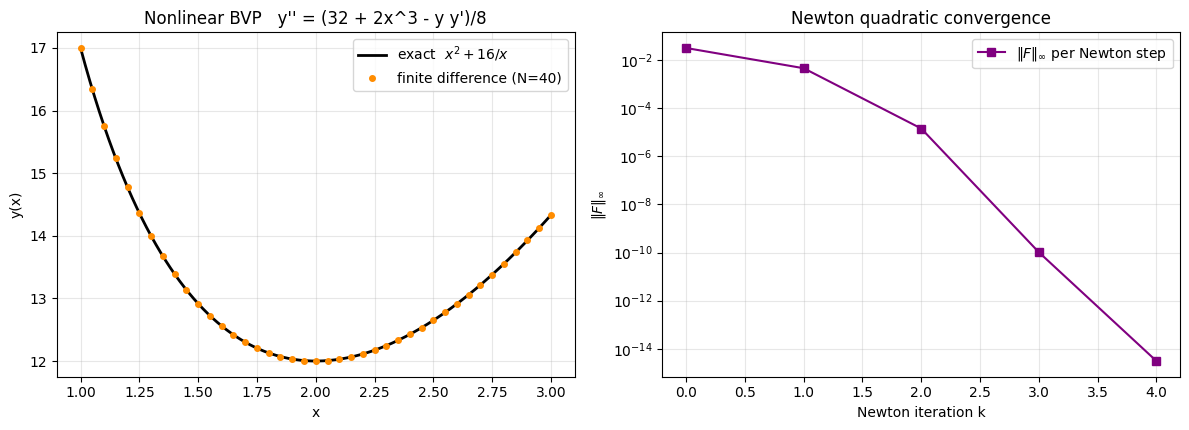

In [5]:
# --- 시각화: (좌) 해 프로파일, (우) Newton 잔차 2차수렴 ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

xs40, y40, hist40 = fd_newton(40)
xx = np.linspace(a, b, 400)
ax[0].plot(xx, exact(xx), "k-", lw=2, label=r"exact  $x^2+16/x$")
ax[0].plot(xs40, y40, "o", ms=4, color="darkorange", label="finite difference (N=40)")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y(x)")
ax[0].set_title("Nonlinear BVP   y'' = (32 + 2x^3 - y y')/8")
ax[0].legend(); ax[0].grid(alpha=.3)

it = np.arange(len(hist40))
ax[1].semilogy(it, hist40, "s-", color="purple", label=r"$\|F\|_\infty$ per Newton step")
ax[1].set_xlabel("Newton iteration k"); ax[1].set_ylabel(r"$\|F\|_\infty$")
ax[1].set_title("Newton quadratic convergence")
ax[1].legend(); ax[1].grid(which="both", alpha=.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **선형계 → 비선형 연립.** $y\,y'$ 항 때문에 문제 1 의 단발 `solve` 가 통하지 않는다.
   Newton 으로 *바깥 루프*를 돌되, 각 스텝의 Jacobian 이 삼중대각이라 *안쪽 풀이*는 여전히 값싸다.
2. **Newton 2차수렴.** $\|\mathbf{F}\|_\infty$ 가 스텝마다 *자릿수가 배로* 줄며 몇 회 만에 기계정밀도
   도달 — 사격의 할선법(초선형 $\varphi\approx1.618$, Day 40)보다 빠른 수렴이다.
3. **같은 답, 다른 길.** 끝점 기울기 $y'(1)\approx-14$ 가 사격의 $s^\star=-14$ 와 일치하고,
   전 구간 해가 $x^2+16/x$ 에 $\mathcal{O}(h^2)$ 로 수렴한다.
4. **강건성.** 직선 초기추정만으로도 발산 없이 수렴 — 사격이 초기기울기 추정에 민감했던 것과 달리,
   유한차분은 경계조건이 처음부터 묶여 있어 초기값에 둔감하다.

> **결론**: 비선형 BVP의 유한차분은 *바깥 Newton(2차수렴) + 안쪽 삼중대각 풀이* 로 구성된다 —
> 사격의 할선보다 빠르고, 초기추정에 강건하며, 같은 $s^\star=-14$ 에 도달한다.

**다음 문제로**: 문제 3 에서 Day 40 사격이 *무너졌던* 강성(stiff) BVP를 가져와, 유한차분이
그 $e^{k}$ 폭발을 어떻게 **회피**하는지 — 즉 *왜 §11.2 가 필요한가* 를 정면으로 확인한다.